# 1. pre-process

Input: 
1. <dataset_name>_participants.tsv: 
study_id | ga_mri_v02 (postmentural weeks)	
1        | 39.43
2. T1w images for :
For UBC-3D, only T1w  
each row in /hpf/largeprojects/smiller/projects/uwo_rcp/Info/Very-Preterm_UBC-Trajectory_Neonatal_3DT1_V02_PMA_at_MRI.xlsx: 
bc_row['study_id']4integal_***.nii, 


Note:
For now, UBC-3D has both preterm and full term baby, so we just try to warp them into 0 and 1 month tpl at first


Process:
1. skull-stripping, already mannually finished by sickkids fellow
2. direct warp (QC check, basic for indirect transfer) testing



In [1]:
import pandas as pd
import os
import sys
base_dir  = "/hpf/largeprojects/smiller/projects/uwo_rcp"
Info_dir  = f"{base_dir}/Info"
pipel_dir = f"{base_dir}/Output"
tpl_root  = f"{base_dir}/NeonatalNormalization/templates"
sys.path.append(f"{base_dir}/NeonatalNormalization/Script")
from tpl_xfm_build import multimodal_register_pipeline

# read the Excel source
df = pd.read_excel(f"{Info_dir}/Very-Preterm_UBC-Trajectory_Neonatal_3DT1_V02_PMA_at_MRI.xlsx")

# write it as CSV
df.to_csv(f"{Info_dir}/Very-Preterm_UBC-Trajectory_Neonatal_3DT1_V02_PMA_at_MRI.csv", index=False, encoding="utf-16")

HPC server:
cd /hpf/largeprojects/smiller/projects/uwo_rcp/
conda activate /hpf/largeprojects/smiller/tools/rcp_pipeline/conda_environments/rcp_env/

## 1.1 Manually skull stripping finished
Visual QC already done

## 1.2 N4 bias correction

In [2]:
import pandas as pd
import os
import sys
import glob
base_dir  = "/hpf/largeprojects/smiller/projects/uwo_rcp"
data_dir = f"{base_dir}/Data"
Info_dir  = f"{base_dir}/Info"
pipel_dir = f"{base_dir}/Output"
tpl_root  = f"{base_dir}/NeonatalNormalization/templates"

dataset_name = "UBC_3D"
dataset_name_exp = "Very-Preterm_UBC-Trajectory_Neonatal_3DT1_V02_SkullStripped_nii"
sys.path.append(f"{base_dir}/NeonatalNormalization/Script")
from tpl_xfm_build import N4_bias_correction
subs_info = pd.read_csv(f"{Info_dir}/Very-Preterm_UBC-Trajectory_Neonatal_3DT1_V02_PMA_at_MRI.csv", encoding="utf-16")
subs_valid = subs_info[subs_info['ga_mri_v02'].notna()]
print(f"Subjects: {len(subs_valid)}")

Subjects: 196


In [3]:
for study_id, row in subs_valid.iterrows(): # .head(10) to have try
    subid = f"bc{int(row['study_id']):04d}"
    print(subid)

    matches = glob.glob(os.path.join(data_dir, dataset_name_exp, f"{subid}*.nii"))
    print(matches)

    # only create the folder if a matching .nii was found
    if matches:
        os.makedirs(os.path.join(pipel_dir, dataset_name, subid), exist_ok=True)

        output_dir  = os.path.join(pipel_dir, dataset_name, subid)
        input_file = matches[0]
        input_name = os.path.basename(input_file)
        if input_name.endswith('.nii.gz'):
            output_name = input_name[:-7] + '_N4.nii.gz'
        elif input_file.endswith('.nii'):
            output_name = input_name[:-4] + '_N4.nii.gz'
        else:
            raise ValueError(f"Not a NIfTI file: {input_name}") 
        output_file = os.path.join(output_dir, output_name)
        print(input_file)
        print(output_file)
        N4_bias_correction(
            input_file  = input_file,
            output_file  = output_file,
            slurm        = True,
        )

bc0001
[]
bc0002
['/hpf/largeprojects/smiller/projects/uwo_rcp/Data/Very-Preterm_UBC-Trajectory_Neonatal_3DT1_V02_SkullStripped_nii/bc0002_20010101_155327_5_mri_3DT1_V02_stripped.nii']
/hpf/largeprojects/smiller/projects/uwo_rcp/Data/Very-Preterm_UBC-Trajectory_Neonatal_3DT1_V02_SkullStripped_nii/bc0002_20010101_155327_5_mri_3DT1_V02_stripped.nii
/hpf/largeprojects/smiller/projects/uwo_rcp/Output/UBC_3D/bc0002/bc0002_20010101_155327_5_mri_3DT1_V02_stripped_N4.nii.gz
[INFO] Submitting job: N4_bc0002
[INFO] Job script: /hpf/largeprojects/smiller/projects/uwo_rcp/Output/UBC_3D/bc0002/log/N4_bc0002.sh
[INFO] sbatch output: Submitted batch job 29391258
[INFO] Job ID: 29391258
bc0003
[]
bc0004
['/hpf/largeprojects/smiller/projects/uwo_rcp/Data/Very-Preterm_UBC-Trajectory_Neonatal_3DT1_V02_SkullStripped_nii/bc0004_20010101_143531_4_mri_3DT1_V02_stripped.nii']
/hpf/largeprojects/smiller/projects/uwo_rcp/Data/Very-Preterm_UBC-Trajectory_Neonatal_3DT1_V02_SkullStripped_nii/bc0004_20010101_143531

# 2. Direct warp to age-specific (0 and 1M tpl)

For each subj, 2 tpls, 1 xfms, 2 warped totally

In [4]:
import pandas as pd
import os
import sys
base_dir  = "/hpf/largeprojects/smiller/projects/uwo_rcp"
data_dir = f"{base_dir}/Data"
Info_dir  = f"{base_dir}/Info"
pipel_dir = f"{base_dir}/Output"
tpl_root  = f"{base_dir}/NeonatalNormalization/templates"

dataset_name = "UBC_3D"
dataset_name_exp = "Very-Preterm_UBC-Trajectory_Neonatal_3DT1_V02_SkullStripped_nii"
sys.path.append(f"{base_dir}/NeonatalNormalization/Script")
from tpl_xfm_build import multimodal_register_pipeline
subs_info = pd.read_csv(f"{Info_dir}/Very-Preterm_UBC-Trajectory_Neonatal_3DT1_V02_PMA_at_MRI.csv", encoding="utf-16")
subs_valid = subs_info[subs_info['ga_mri_v02'].notna()]
print(f"Subjects: {len(subs_valid)}")

Subjects: 196


In [5]:
import glob
import os

xfm_mods = ['T1']
TPL_FIX_months = ["00", "01"]

for study_id, row in subs_valid.iterrows():
    subid = f"bc{int(row['study_id']):04d}"
    print(subid)
    output_dir  = os.path.join(pipel_dir, dataset_name, subid)
    matches = glob.glob(os.path.join(output_dir, f"{subid}*.nii.gz"))
    print(matches)

    # only create the folder if a matching .nii was found
    if matches:
        os.makedirs(os.path.join(pipel_dir, dataset_name, subid), exist_ok=True)
        input_files = {
            "T1": matches[0],
        }

        for xfm in xfm_mods:
            for TPL_FIX in TPL_FIX_months:
                print(f"\n=== Step 1: direct registration to {TPL_FIX}M ===")
                multimodal_register_pipeline(
                    modalities   = xfm,
                    input_files  = input_files,
                    tpl_root     = tpl_root,
                    tpl_month    = TPL_FIX,
                    output_dir   = output_dir,
                    steps        = [1, 2, 3, 4],
                    slurm        = True,
                )

bc0001
[]
bc0002
['/hpf/largeprojects/smiller/projects/uwo_rcp/Output/UBC_3D/bc0002/bc0002_20010101_155327_5_mri_3DT1_V02_stripped_N4.nii.gz']

=== Step 1: direct registration to 00M ===
[INFO] Submitting job: T1_00Mtpl
[INFO] Job script: /hpf/largeprojects/smiller/projects/uwo_rcp/Output/UBC_3D/bc0002/log/T1_00Mtpl.sh
[INFO] sbatch output: Submitted batch job 29391430
[INFO] Job ID: 29391430

=== Step 1: direct registration to 01M ===
[INFO] Submitting job: T1_01Mtpl
[INFO] Job script: /hpf/largeprojects/smiller/projects/uwo_rcp/Output/UBC_3D/bc0002/log/T1_01Mtpl.sh
[INFO] sbatch output: Submitted batch job 29391431
[INFO] Job ID: 29391431
bc0003
[]
bc0004
['/hpf/largeprojects/smiller/projects/uwo_rcp/Output/UBC_3D/bc0004/bc0004_20010101_143531_4_mri_3DT1_V02_stripped_N4.nii.gz']

=== Step 1: direct registration to 00M ===
[INFO] Submitting job: T1_00Mtpl
[INFO] Job script: /hpf/largeprojects/smiller/projects/uwo_rcp/Output/UBC_3D/bc0004/log/T1_00Mtpl.sh
[INFO] sbatch output: Submitte

# 3. Visual QC and R to tpl

In [ ]:
# Check how many subs has output already
import os

path = "/hpf/largeprojects/smiller/projects/uwo_rcp/Output/UBC_3D"
count = sum(1 for entry in os.scandir(path) if entry.is_dir())
print('We have finished these subjects: ')
print(count)

142


In [6]:
subjects

['bc0002',
 'bc0004',
 'bc0006',
 'bc0007',
 'bc0010',
 'bc0011',
 'bc0013',
 'bc0014',
 'bc0015',
 'bc0017',
 'bc0018',
 'bc0019',
 'bc0020',
 'bc0021',
 'bc0023',
 'bc0024',
 'bc0025',
 'bc0026',
 'bc0027',
 'bc0028',
 'bc0030',
 'bc0032',
 'bc0035',
 'bc0037',
 'bc0038',
 'bc0041',
 'bc0042',
 'bc0043',
 'bc0044',
 'bc0046',
 'bc0049',
 'bc0050',
 'bc0051',
 'bc0052',
 'bc0053',
 'bc0056',
 'bc0057',
 'bc0058',
 'bc0060',
 'bc0061',
 'bc0062',
 'bc0063',
 'bc0064',
 'bc0065',
 'bc0066',
 'bc0067',
 'bc0068',
 'bc0069',
 'bc0070',
 'bc0071',
 'bc0072',
 'bc0077',
 'bc0078',
 'bc0079',
 'bc0081',
 'bc0082',
 'bc0083',
 'bc0085',
 'bc0088',
 'bc0089',
 'bc0091',
 'bc0092',
 'bc0093',
 'bc0094',
 'bc0095',
 'bc0097',
 'bc0098',
 'bc0100',
 'bc0101',
 'bc0102',
 'bc0103',
 'bc0104',
 'bc0105',
 'bc0106',
 'bc0111',
 'bc0118',
 'bc0119',
 'bc0120',
 'bc0128',
 'bc0129',
 'bc0130',
 'bc0131',
 'bc0133',
 'bc0134',
 'bc0136',
 'bc0137',
 'bc0138',
 'bc0141',
 'bc0143',
 'bc0147',
 'bc0148',

In [7]:
sub

'bc0271'

In [8]:
BASE / sub / info["suffix"]

PosixPath('/hpf/largeprojects/smiller/projects/uwo_rcp/Output/UBC_3D/bc0271/T1_resliced_to_01Mtpl_by_direct_T1_xfm.nii.gz')

In [10]:
img_path

PosixPath('/hpf/largeprojects/smiller/projects/uwo_rcp/Output/UBC_3D/bc0271/T1_resliced_to_01Mtpl_by_direct_T1_xfm.nii.gz')

In [11]:
np.corrcoef(img[mask], tpl[mask])[0, 1]

TypeError: 'PosixPath' object is not subscriptable

Subjects with PMA: 196


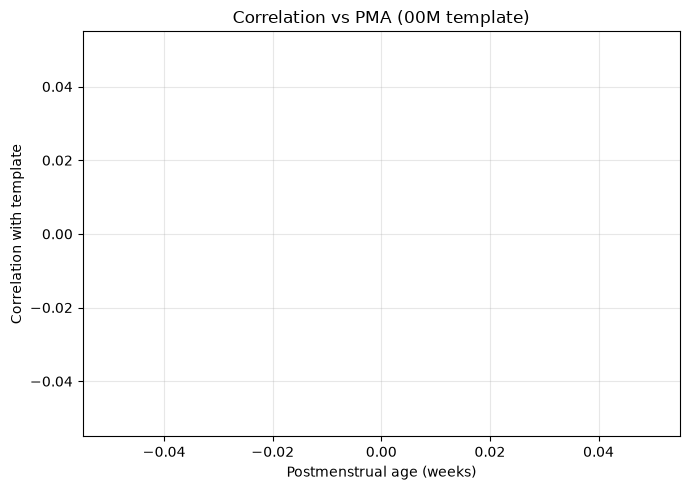

00M: 0 subjects plotted


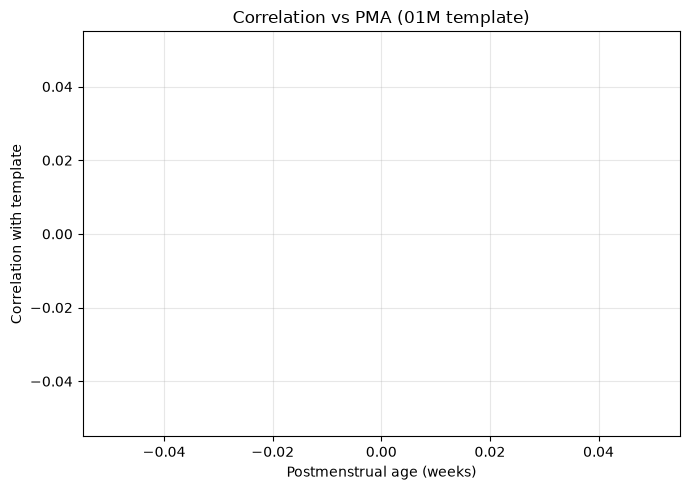

01M: 0 subjects plotted


In [9]:
import os
from pathlib import Path

import numpy as np
import pandas as pd
import nibabel as nib
import matplotlib.pyplot as plt

base_dir = "/hpf/largeprojects/smiller/projects/uwo_rcp"
BASE     = Path(base_dir) / "Output" / "UBC_3D"
tpl_root = Path(base_dir) / "NeonatalNormalization" / "templates"
info_csv = Path(base_dir) / "Info" / "Very-Preterm_UBC-Trajectory_Neonatal_3DT1_V02_PMA_at_MRI.csv"

# --- PMA lookup: study_id -> ga_mri_v02 ---
info = pd.read_csv(info_csv, encoding="utf-16")
info = info[info["ga_mri_v02"].notna()]
pma_map = dict(zip(info["study_id"].astype(str), info["ga_mri_v02"]))
print(f"Subjects with PMA: {len(pma_map)}")

# --- Templates + matching resliced filenames ---
templates = {
    "00M": (tpl_root / "00Month/BCP-00M-T1.nii.gz", "T1_resliced_to_00Mtpl_by_direct_T1_xfm.nii.gz"),
    "01M": (tpl_root / "01Month/BCP-01M-T1.nii.gz", "T1_resliced_to_01Mtpl_by_direct_T1_xfm.nii.gz"),
}

subjects = sorted(p.name for p in os.scandir(BASE) if p.is_dir())

for label, (tpl_path, suffix) in templates.items():
    tpl = nib.load(str(tpl_path)).get_fdata()
    mask = tpl > 0

    ages, corrs = [], []
    for sub in subjects:
        img_path = BASE / sub / suffix
        if not img_path.exists() or sub not in pma_map:
            continue
        img = nib.load(str(img_path)).get_fdata()
        if img.shape != tpl.shape:
            continue
        r = np.corrcoef(img[mask], tpl[mask])[0, 1]
        print(f"{sub}: {r:.3f}")
        ages.append(pma_map[sub])
        corrs.append(r)

    plt.figure(figsize=(7, 5))
    plt.scatter(ages, corrs, s=25, alpha=0.8)
    plt.xlabel("Postmenstrual age (weeks)")
    plt.ylabel("Correlation with template")
    plt.title(f"Correlation vs PMA ({label} template)")
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()
    print(f"{label}: {len(corrs)} subjects plotted")

# 4. Cereb mask dice score?